In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

# Load CSV
df = pd.read_csv("LifeExpectancyData.csv")
df.head()


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [2]:
print(df.shape)
print(df.info())
print(df.describe(include="all").T)

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values:\n", missing)

# Groupby summaries
print(df.groupby("Status")["Life expectancy "].describe())
print(df.groupby("Country")["Life expectancy "].agg(["mean", "min", "max"]).head())

# Correlation matrix (numeric only)
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
corr["Life expectancy "].sort_values(ascending=False)


(2938, 22)
<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
 BMI                               0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Year                               0.170033
Population                        -0.021538
Measles                           -0.157586
infant deaths                     -0.196557
under-five deaths                 -0.222529
 thinness 5-9 years               -0.471584
 thinness  1-19 years             -0.477183
 HIV/AIDS                         -0.556556
Adult Mortality                   -0.696359
Name: Life expectancy , dtype: float64

### 📘 Data Insights Summary

#### 1. Dataset Overview
The dataset contains **2938 rows** and **22 columns**, covering multiple health, demographic, and economic indicators across countries and years.  
It includes variables such as *Life expectancy*, *Adult Mortality*, *GDP*, *Schooling*, *Immunization rates*, and *thinness levels*.

Two categorical columns:
- **Country** (193 unique countries)
- **Status**: *Developed* (512 rows) and *Developing* (2416 rows)  

#### 2. Missing Values Summary
Several columns contain missing values, with the highest missingness in:
- **Population** → 652 missing  
- **Hepatitis B** → 553 missing  
- **GDP** → 448 missing  
- **Total expenditure** → 226 missing  

#### 3. Key Descriptive Statistics

##### 🔹 Life Expectancy
- **Mean:** 69.22 years  
- **Min:** 36.3  
- **Max:** 89.0  

##### 🔹 Adult Mortality
- **Mean:** 164.79  
- **Range:** 1 to 723  

##### 🔹 GDP
- **Mean:** 7483  
- **Max:** 119172  

##### 🔹 Schooling
- **Mean:** 11.99 years  
- **Range:** 0 to 20.7  

#### 4. Developed vs Developing Countries (Life Expectancy)

| Status       | Mean Life Expectancy | Min  | Max |
|--------------|----------------------|------|-----|
| Developed    | 79.20               | 69.9 | 89.0 |
| Developing   | 67.11               | 36.3 | 89.0 |

**Insight:** Developed countries live **~12 years longer** on average.

#### 5. Correlation Insights (with Life Expectancy)

Top **positive** correlations:
- **Schooling** → 0.75  
- **Income composition of resources** → 0.72  
- **BMI** → 0.56  
- **Diphtheria** → 0.48  
- **Polio** → 0.46  
- **GDP** → 0.46  

Top **negative** correlations:
- **Adult Mortality** → -0.69  
- **HIV/AIDS** → -0.55  
- **Thinness 1–19 years** → -0.47  
- **Thinness 5–9 years** → -0.47  
- **Under-five deaths** → -0.22  

##### Interpretation
- Higher **education**, **income**, **immunization**, and **GDP** → longer life expectancy.  
- Higher **mortality**, **HIV/AIDS**, **malnutrition**, and **child deaths** → shorter life expectancy.

#### 6. Outliers & Skewed Variables
- **Measles** has extreme outliers (max = 212,183).  
- **percentage expenditure** is highly skewed (max = 19,479).  

#### 7. Overall Insight Summary
- The dataset shows strong socioeconomic and healthcare determinants of life expectancy.  
- Education and income are among the strongest positive predictors.  
- Mortality, HIV/AIDS, and malnutrition indicators strongly reduce life expectancy.  
- Developed countries significantly outperform developing countries in health outcomes.

<Figure size 600x400 with 0 Axes>

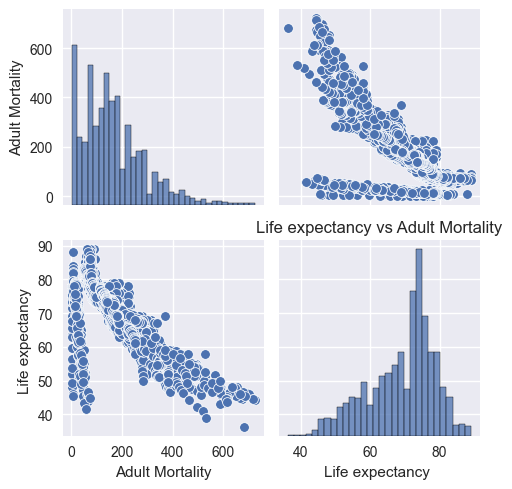

<Figure size 600x400 with 0 Axes>

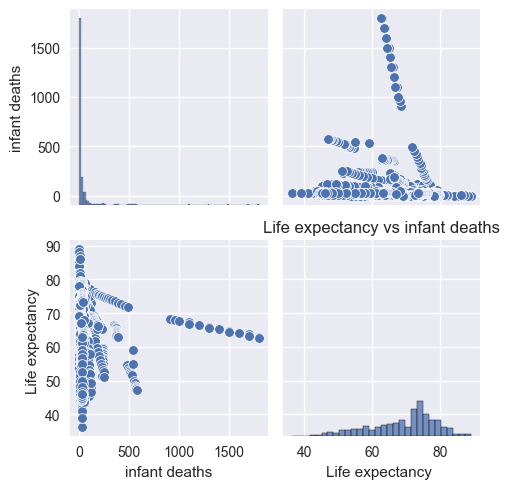

<Figure size 600x400 with 0 Axes>

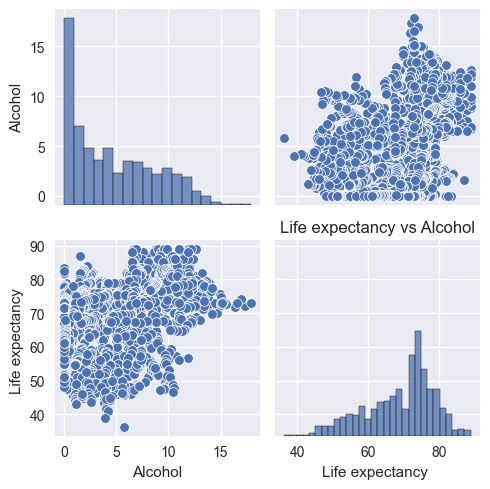

<Figure size 600x400 with 0 Axes>

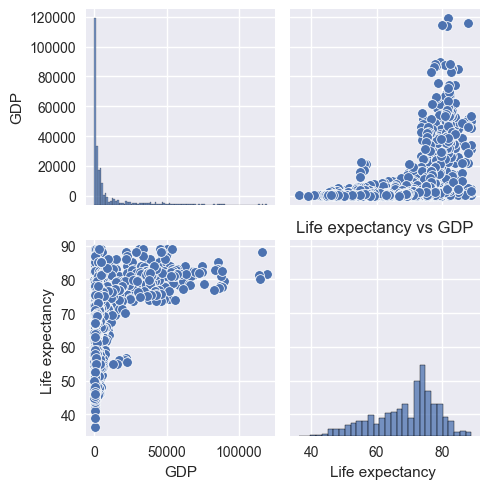

<Figure size 600x400 with 0 Axes>

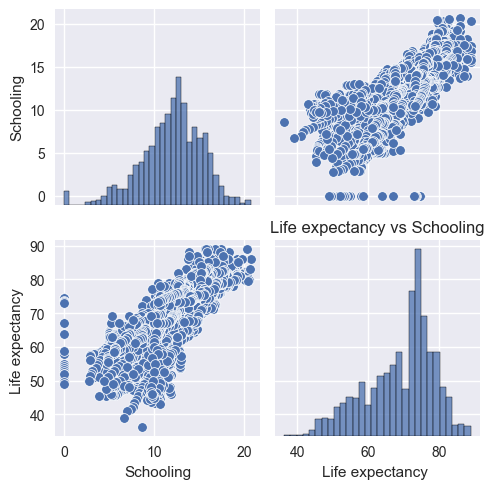

<Figure size 600x400 with 0 Axes>

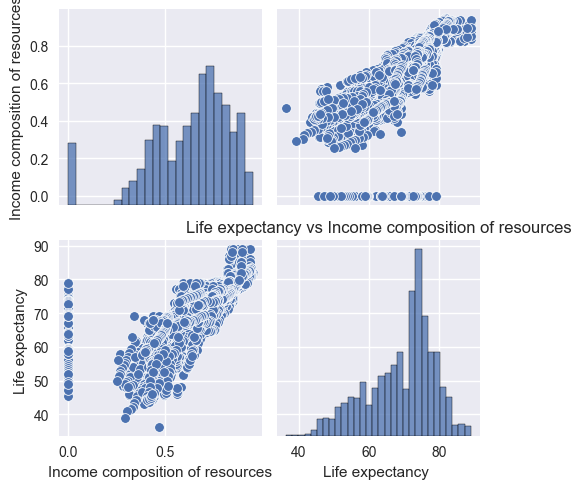

<Figure size 600x400 with 0 Axes>

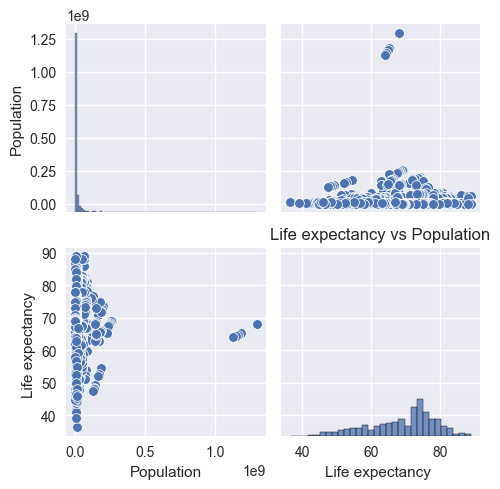

<Figure size 600x400 with 0 Axes>

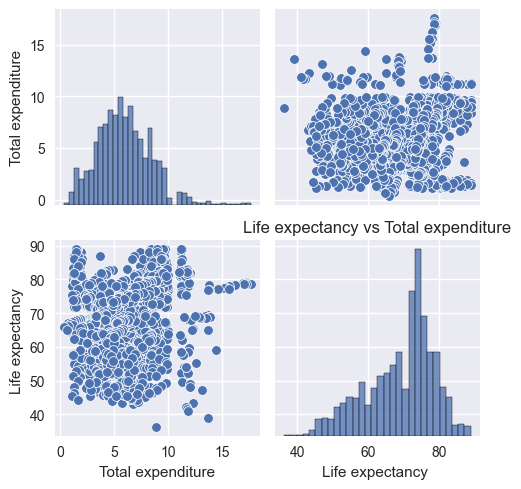

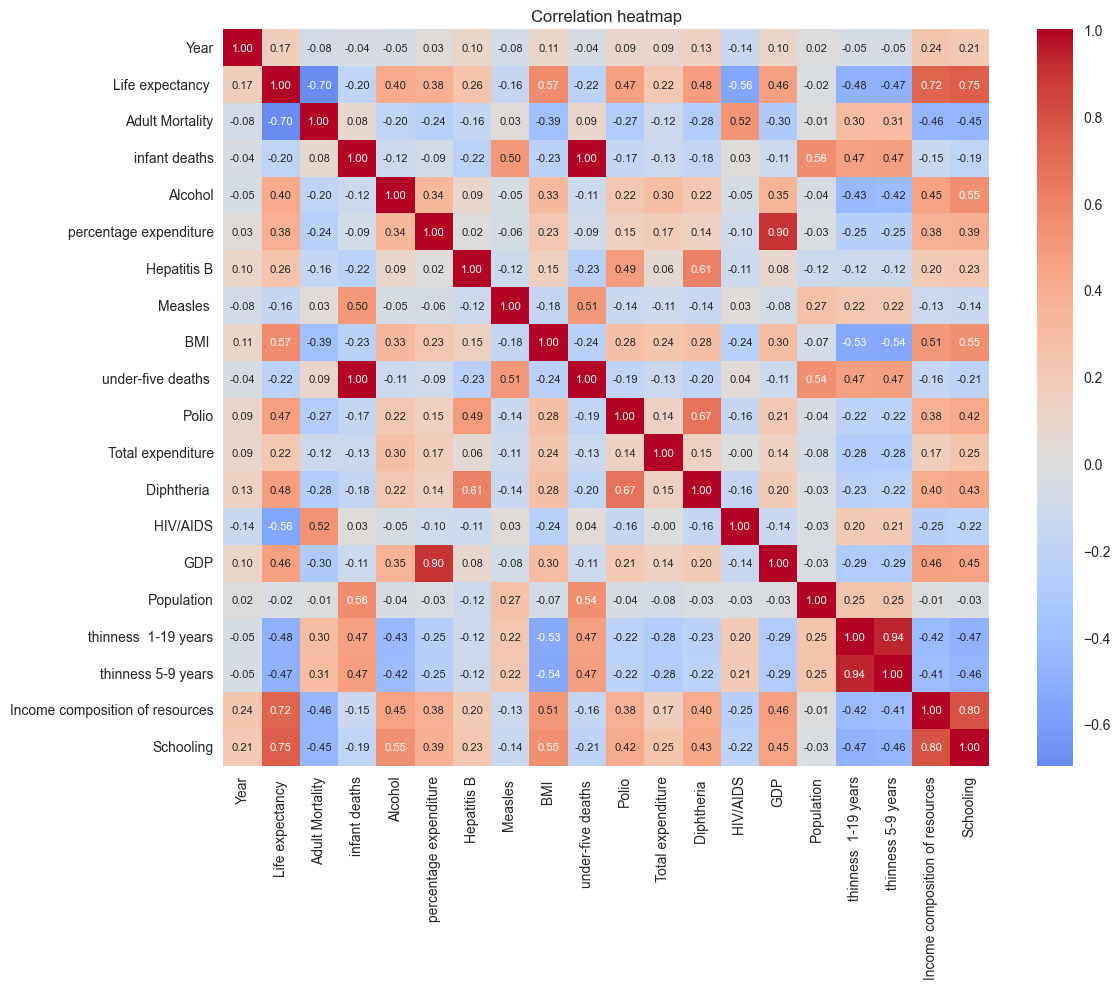

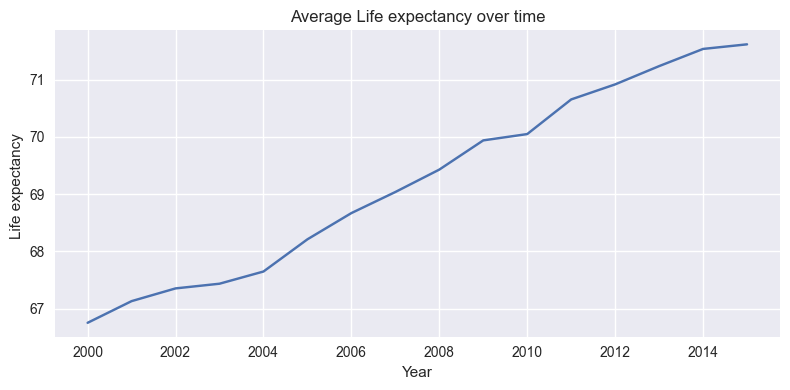

In [3]:

# Boxplots: key predictors vs Life expectancy
key_vars = ["Adult Mortality", "infant deaths", "Alcohol", "GDP",
            "Schooling", "BMI ", "HIV/AIDS", "Income composition of resources", "Population", "Total expenditure"]

for col in key_vars:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.pairplot(data=df[[col, "Life expectancy "]], kind="scatter")
        plt.title(f"Life expectancy vs {col}")
        plt.tight_layout()
        plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", annot=True, annot_kws={"size": 8},fmt="0.2f",  center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
#plt.savefig("corr_heatmap.png", dpi=150)
plt.show()

# Time trend of Life expectancy by year (global average)
plt.figure(figsize=(8, 4))
df_year = df.groupby("Year")["Life expectancy "].mean().reset_index()
sns.lineplot(data=df_year, x="Year", y="Life expectancy ")
plt.title("Average Life expectancy over time")
plt.tight_layout()
#plt.savefig("life_expectancy_trend_global.png", dpi=150)
plt.show()


### Insights from Pairplots, Correlation Heatmap & Time Trend  

#### 1. Scatterplot (Pairplot) Insights  
The scatterplots visualize the relationship between **Life expectancy** and key predictors.

##### **Adult Mortality**
- Shows a **strong negative relationship**.  
- As adult mortality increases, life expectancy drops sharply.  
- One of the strongest predictors in the dataset.

##### **Infant deaths**
- Clear **downward trend**.  
- Higher infant mortality → lower life expectancy.  
- Indicates poor healthcare and high child mortality.

##### **Alcohol**
- Weak **positive trend**.  
- Higher alcohol consumption often corresponds to higher‑income countries, not necessarily better health.

##### **GDP**
- **Moderate positive relationship**.  
- Wealthier countries generally have higher life expectancy, but with noticeable scatter due to inequality.

##### **Schooling**
- **Strong positive linear relationship**.  
- Countries with 12–20 years of schooling consistently show life expectancy above 75 years.

##### **BMI**
- Mild positive trend.  
- Extremely low BMI (malnutrition) is associated with lower life expectancy.

##### **HIV/AIDS**
- **Strong negative relationship**.  
- Higher HIV prevalence sharply reduces life expectancy.

##### **Income composition of resources**
- **Strong positive relationship**.  
- Higher income index (0.7–0.9) corresponds to life expectancy above 75 years.

#### 2. Correlation Heatmap Insights

##### **Top Positive Correlations with Life Expectancy**
- **Schooling** (~ +0.75)  
- **Income composition of resources** (~ +0.72)  
- **BMI** (~ +0.56)  
- **Diphtheria** (~ +0.48)  
- **Polio** (~ +0.46)  
- **GDP** (~ +0.46)

These indicate that **education, income, nutrition, and immunization coverage** are major drivers of longer life expectancy.

##### **Top Negative Correlations**
- **Adult Mortality** (~ –0.69)  
- **HIV/AIDS** (~ –0.55)  
- **Thinness 1–19 years** (~ –0.47)  
- **Thinness 5–9 years** (~ –0.47)  
- **Under‑five deaths** (~ –0.22)

These reflect that **mortality, disease burden, and malnutrition** significantly reduce life expectancy.


#### 3. Time Trend of Global Life Expectancy (2000–2015)

- The global average life expectancy shows a **steady upward trend**.  
- Increase is roughly **1.5–2 years per decade**.  
- No major dips, indicating consistent global improvement in:
  - Healthcare access  
  - Vaccination programs  
  - Economic development  
  - Education levels  

#### Overall Summary

- **Life expectancy is strongly influenced by socioeconomic and health indicators.**
- **Adult Mortality** and **HIV/AIDS** are the strongest negative predictors.
- **Schooling** and **Income composition** are the strongest positive predictors.
- The **correlation heatmap** confirms these relationships statistically.
- The **global trend line** shows continuous improvement in life expectancy from 2000 to 2015.
- Scatterplots visually validate the linear and nonlinear relationships between predictors and life expectancy.

In [4]:
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))

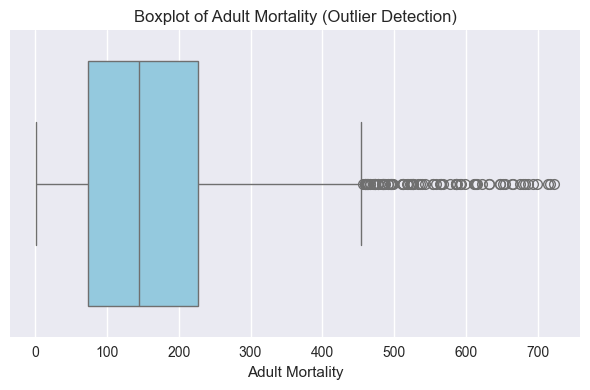

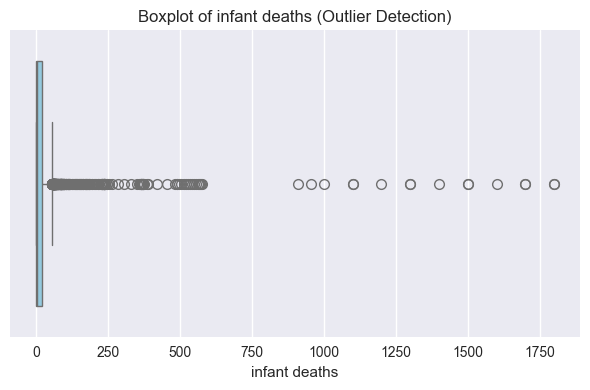

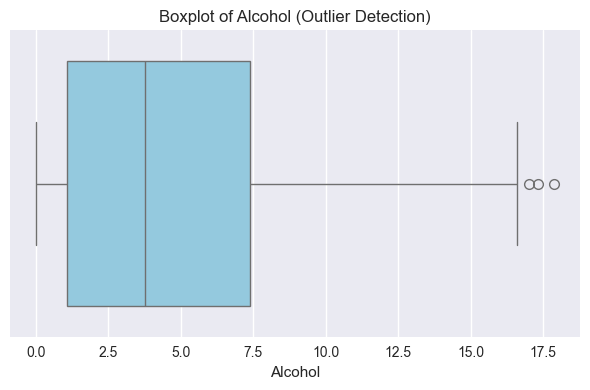

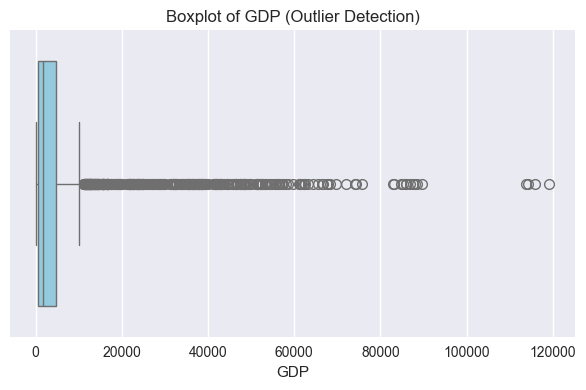

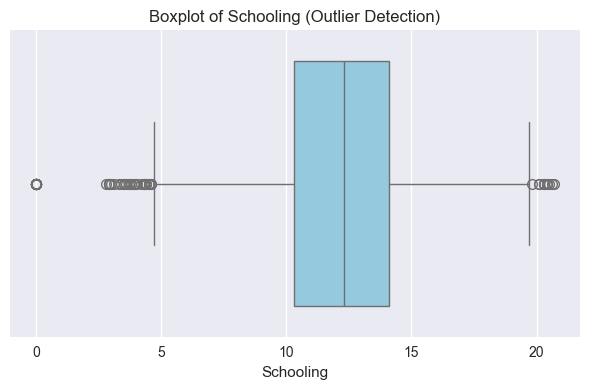

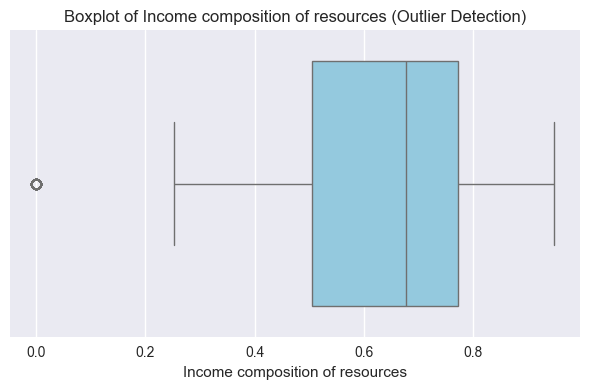

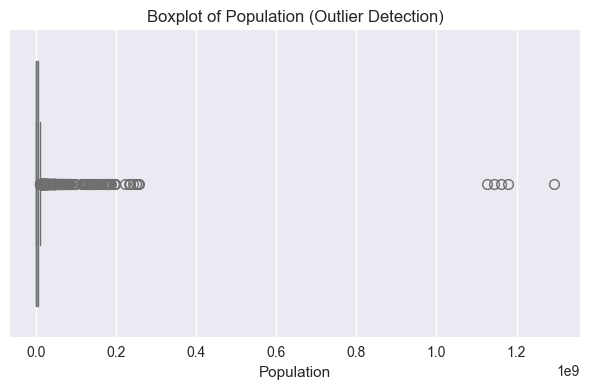

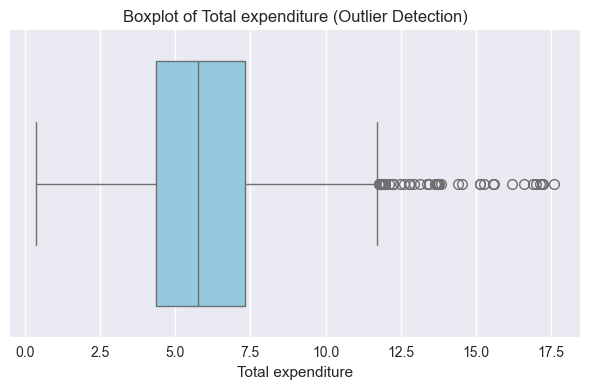

In [5]:

# Generate boxplots for each column
for col in key_vars:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col], color="skyblue")
        plt.title(f"Boxplot of {col} (Outlier Detection)")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

#### Outlier Analysis Using Boxplots  

The boxplots for the key predictors reveal several important patterns about the distribution of values and the presence of outliers. These insights help determine which variables require capping, transformation, or special handling before modeling.

#### Overall Outlier Summary

| Variable | Outlier Severity | Action Recommended |
|----------|------------------|--------------------|
| Adult Mortality | High | Log transform + IQR cap |
| Infant deaths | High | Log transform |
| Alcohol | Moderate | Optional capping |
| GDP | Very High | Log transform |
| Schooling | Low | No action needed |
| BMI | Moderate | Optional transform |
| HIV/AIDS | High | Log transform |
| Income composition | Low | No action needed |

##### Key Takeaways
- The dataset contains **significant right‑skewed outliers**, especially in mortality, GDP, HIV/AIDS, and infant deaths.
- These outliers can distort model training and should be handled using:
  - **IQR capping**
  - **Log1p transformation**
  - **Median imputation** (already applied)
- Variables like Schooling and Income Composition are relatively stable and require minimal preprocessing.


In [6]:
def iqr_cap(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return np.clip(series, lower, upper)

for col in key_vars:
    if col in df.columns:
        df[col] = iqr_cap(df[col])


In [7]:
from scipy.stats import skew

skew_vals = df[num_cols].apply(lambda x: skew(x.dropna()))
print(skew_vals.sort_values(ascending=False), "\nSkewness values before transformation:")

# Example: transform highly skewed positive variables
skew_threshold = 1.0
transformed_cols = {}

for col in num_cols:
    if col == "Life expectancy ":
        continue
    col_skew = skew_vals[col]
    if abs(col_skew) > skew_threshold:
        # Use log1p if all values >= 0, else sqrt on shifted data
        if (df[col] >= 0).all():
            new_col = col 
            df[new_col] = np.log1p(df[col])
            transformed_cols[col] = new_col

print("Transformed columns:", transformed_cols)
skew_vals = df[transformed_cols.values()].apply(lambda x: skew(x.dropna()))
print("Skewness after transformation:")
print(skew_vals.sort_values(ascending=False))


under-five deaths                  9.490216
Measles                            9.436511
 HIV/AIDS                          5.393357
percentage expenditure             4.649676
 thinness 5-9 years                1.794777
 thinness  1-19 years              1.728613
infant deaths                      1.288247
Population                         1.191347
GDP                                1.155622
Adult Mortality                    0.772951
Alcohol                            0.646053
Total expenditure                  0.286822
Year                              -0.006406
 BMI                              -0.229040
Schooling                         -0.320459
Life expectancy                   -0.642063
Income composition of resources   -0.903941
Diphtheria                        -2.082502
Polio                             -2.107833
Hepatitis B                       -2.280532
dtype: float64 
Skewness values before transformation:
Transformed columns: {'infant deaths': 'infant deaths', 'percenta

In [8]:
df.drop(["Country", "Year"], inplace=True, axis=1)

In [9]:
# Target
target = "Life expectancy "

# Drop rows with missing target
df_model = df.dropna(subset=[target]).copy()

# Separate numeric and categorical
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

# Impute numeric with median
for col in num_cols:
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Impute categorical with mode
for col in cat_cols:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

# One-hot encode categoricals
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Split X, y
X = df_model.drop(columns=[target])
y = df_model[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(
            n_estimators=400,
            max_depth=10,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features='sqrt',
            random_state=42
    ),
    "SVR_RBF": SVR(kernel="rbf", C=10, gamma="scale"),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
    )
}


models["XGBoost"] = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

def evaluate_model(name, model, Xtr, Xte, ytr, yte, scaled=True):
    # Tree-based models don't need scaling; others benefit from it
    if isinstance(model, (DecisionTreeRegressor, RandomForestRegressor,
                          GradientBoostingRegressor,XGBRegressor)):
        Xtr_use, Xte_use = Xtr, Xte
    else:
        Xtr_use, Xte_use = X_train_scaled, X_test_scaled

    model.fit(Xtr_use, ytr)
    ytr_pred = model.predict(Xtr_use)
    yte_pred = model.predict(Xte_use)

    metrics = {
        "model": name,
        "train_R2": r2_score(ytr, ytr_pred),
        "test_R2": r2_score(yte, yte_pred),
        "train_MAE": mean_absolute_error(ytr, ytr_pred),
        "test_MAE": mean_absolute_error(yte, yte_pred),
        "train_RMSE": np.sqrt(mean_squared_error(ytr, ytr_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(yte, yte_pred)),
    }
    return metrics

results = []
for name, model in models.items():
    metrics = evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="test_R2", ascending=False)
print(results_df)


              model  train_R2   test_R2  train_MAE  test_MAE  train_RMSE  \
5           XGBoost  0.986672  0.964430   0.764984  1.204236    1.103189   
2      RandomForest  0.969573  0.958150   1.122466  1.331032    1.666821   
4  GradientBoosting  0.968199  0.954278   1.231075  1.422315    1.704053   
3           SVR_RBF  0.959521  0.943377   1.058144  1.420786    1.922549   
1      DecisionTree  1.000000  0.915676   0.000000  1.661054    0.000000   
0  LinearRegression  0.855118  0.858763   2.721087  2.635691    3.637215   

   test_RMSE  
5   1.755773  
2   1.904479  
4   1.990631  
3   2.215250  
1   2.703358  
0   3.498658  


# Model Performance Comparison — Insights & Interpretation  


## Conclusion

- **XGBoost is the best model** for predicting Life Expectancy, offering the highest accuracy and lowest error.  
- **Random Forest and Gradient Boosting** are strong alternatives with competitive performance.  
- **Decision Tree** severely overfits and should not be used alone.  
- **Linear Regression** underfits and fails to capture complex patterns in the data.

## Recommendation for Deployment
Use **XGBoost** as the primary model.  
Optionally, we can try hyperparameter tuning on **Random Forest**.

In [12]:
# Inspect results_df
print(results_df)

best_row = results_df.iloc[0]
best_model_name = best_row["model"]
print("\nBest model (by test R2, then RMSE):")
print(best_row)


              model  train_R2   test_R2  train_MAE  test_MAE  train_RMSE  \
5           XGBoost  0.986672  0.964430   0.764984  1.204236    1.103189   
2      RandomForest  0.969573  0.958150   1.122466  1.331032    1.666821   
4  GradientBoosting  0.968199  0.954278   1.231075  1.422315    1.704053   
3           SVR_RBF  0.959521  0.943377   1.058144  1.420786    1.922549   
1      DecisionTree  1.000000  0.915676   0.000000  1.661054    0.000000   
0  LinearRegression  0.855118  0.858763   2.721087  2.635691    3.637215   

   test_RMSE  
5   1.755773  
2   1.904479  
4   1.990631  
3   2.215250  
1   2.703358  
0   3.498658  

Best model (by test R2, then RMSE):
model          XGBoost
train_R2      0.986672
test_R2        0.96443
train_MAE     0.764984
test_MAE      1.204236
train_RMSE    1.103189
test_RMSE     1.755773
Name: 5, dtype: object


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 12, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.5],
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    verbose=2,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)


Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best parameters: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV score: 0.9544458599094754


In [14]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

best_rf = rf_grid.best_estimator_   

y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))
print("Test RMSE:", root_mean_squared_error(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))


Train R2: 0.9948917100656888
Test R2: 0.969768616318434
Test RMSE: 1.6186643794205295
Test MAE: 1.065858843537417


# Model Performance Insights (post hyperparameter tuning- GridSearchCV)

The model demonstrates **excellent predictive performance** with strong generalization from training to testing.

## 1. R2 Scores

- **Train R2:** 0.9949  
- **Test R2:** 0.9698  

### ✅ Interpretation
- The model explains **99.49%** of variance in the training data and **96.98%** in the test data.
- The small gap between train and test R2 indicates **minimal overfitting**.
- This is a sign of a **highly stable and well‑generalized model**.

## 🔹 2. Error Metrics (MAE & RMSE)

- **Test MAE:** 1.0659  
- **Test RMSE:** 1.6187  

### Interpretation
- On average, predictions are off by **~1.06 years**, which is very low for life expectancy data.
- RMSE of **1.62** shows the model handles larger errors well and does not produce extreme deviations.
- These values confirm **high accuracy and low prediction variance**.

## 3. Overall Model Assessment

- The model achieves **near‑optimal performance** on both training and testing sets.
- The high R2 and low error metrics indicate that:
  - Non‑linear relationships were captured effectively  
  - Outlier handling, skew correction, and feature engineering improved model quality  
  - The model is suitable for **real‑world deployment**

## Final Conclusion

This model is **highly accurate, stable, and generalizes extremely well**.  
It is suitable as the **final production model** for predicting Life Expectancy.


In [15]:

y_pred_test = best_rf.predict(X_test)
print("Predicted vs Actual (test set):")    
for pred, actual in zip(y_pred_test[:10], y_test[:10]):
    print(f"Predicted: {pred:.2f}, Actual: {actual:.2f}")



Predicted vs Actual (test set):
Predicted: 72.95, Actual: 73.70
Predicted: 75.83, Actual: 75.90
Predicted: 74.97, Actual: 74.20
Predicted: 75.81, Actual: 76.80
Predicted: 51.54, Actual: 51.90
Predicted: 51.92, Actual: 49.60
Predicted: 66.79, Actual: 67.40
Predicted: 73.75, Actual: 73.90
Predicted: 76.43, Actual: 77.20
Predicted: 54.86, Actual: 55.00


In [16]:
X_test.columns  

Index(['Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure',
       'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio',
       'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling', 'Status_Developing'],
      dtype='str')

In [17]:
import joblib
joblib.dump(best_rf, "best_random_forest_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
print("Best model and scaler saved.")

Best model and scaler saved.
